[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lshofsl/Advanced-topics-in-PoD-project-/blob/main/EBM_NCA_baseline.ipynb)

In [1]:
# Baseline NCA adapted
# @misc{guichard2025engramncaneuralcellularautomaton,
     # title={EngramNCA: a Neural Cellular Automaton Model of Memory Transfer},
     # author={Etienne Guichard and Felix Reimers and Mia Kvalsund and Mikkel Lepperød and Stefano Nichele},
     # year={2025},
     # eprint={2504.11855},
     # archivePrefix={arXiv},
     # primaryClass={cs.NE},
     # url={https://arxiv.org/abs/2504.11855},
#}



import os
import sys

!rm -rf Advanced-topics-in-PoD-project-
!git clone https://github.com/lshofsl/Advanced-topics-in-PoD-project-.git

repo_path = os.path.abspath("Advanced-topics-in-PoD-project-")
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

if os.path.exists(repo_path):
    print("Success! Files now found:", os.listdir(repo_path))

Cloning into 'Advanced-topics-in-PoD-project-'...
remote: Enumerating objects: 393, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 393 (delta 35), reused 29 (delta 13), pack-reused 322 (from 1)
Receiving objects: 100% (393/393), 14.74 MiB | 12.35 MiB/s, done.
Resolving deltas: 100% (220/220), done.
Success! Files now found: ['NCA.py', '.git', 'utils.py', 'EBM_NCA_baseline.ipynb', 'README.md', 'EBM_NCA.ipynb', 'NCA_baseline.py', 'Images', 'CRBM_NCA.ipynb', 'pathway.py']


In [2]:

#@title Imports { vertical-output: true}
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

from NCA import *
import utils as utils
from IPython.display import Image, HTML, clear_output
import torch.nn.functional as F
import logging
from IPython.display import display, HTML, Video
from PIL import Image
import cv2
from base64 import b64encode
from sklearn.decomposition import PCA
logger = logging.getLogger()
old_level = logger.level
logger.setLevel(100)


Using device: cuda


In [3]:
#@title Setup { vertical-output: true}
HEIGHT = 35 #@param {type:"integer"}
WIDTH = 35 #@param {type:"integer"}
CHANNELS = 16 # @param {type:"integer"}<--- NCA feature channels
BATCH_SIZE = 12 #@param {type:"integer"}
PADDING = 5 #@param {type:"integer"}
POOL_SIZE = 2666 #@param {type:"integer"}<--- NCA training pool size, lower values train faster but are less stable
TRAINING_ITERS = 5000  #@param {type:"integer"}<-- Number of trainign iterations
HIDDEN_SIZE = 64 #@param {type:"integer"}<--- NCA hidden size


style = """
<style>
.output_wrapper, .output {
    display: flex;
    flex-direction: row-reverse; /* Align content to the right */
}
</style>
"""


In [4]:
#@title Load Primitives { vertical-output: true}

LIZARD = "Images/lizard.png"
path = LIZARD
image, image_to_display = utils.get_image(os.path.join(repo_path, path), HEIGHT, WIDTH, padding=PADDING)

HEIGHT = HEIGHT + 2*PADDING
WIDTH = WIDTH + 2*PADDING


In [5]:
class SamplePool:
  def __init__(self, *, _parent=None, _parent_idx=None, **slots):
    self._parent = _parent
    self._parent_idx = _parent_idx
    self._slot_names = slots.keys()
    self._size = None
    for k, v in slots.items():
      if self._size is None:
        self._size = len(v)
      assert self._size == len(v)
      setattr(self, k, np.asarray(v))

  def sample(self, n):
    idx = np.random.choice(self._size, n, False)
    batch = {k: getattr(self, k)[idx] for k in self._slot_names}
    batch = SamplePool(**batch, _parent=self, _parent_idx=idx)
    return batch

  def commit(self):
    for k in self._slot_names:
      getattr(self._parent, k)[self._parent_idx] = getattr(self, k)

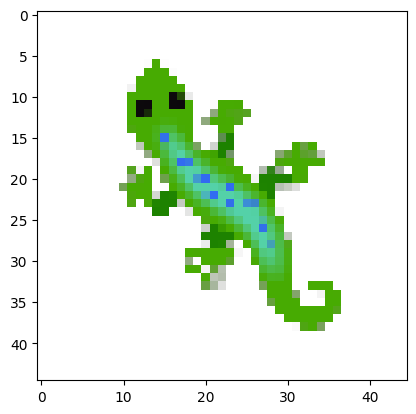

In [6]:
#@title Display Primitives { vertical-output: true}
seed = np.zeros([CHANNELS, HEIGHT, WIDTH], np.float32)
seed[3:, HEIGHT // 2, WIDTH // 2] = 1.0

pool = SamplePool(x=np.repeat(seed[None, ...], POOL_SIZE, axis=0))


plt.imshow(image_to_display)
plt.show()


In [7]:
#@title Get Batch Image Partitions { vertical-output: true}
batch = pool.sample(BATCH_SIZE)

In [8]:
#@title Load Filters for Loss Function { vertical-output: true}

sobel_x = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]], dtype=torch.float32, device=DEVICE)
lap = torch.tensor([[1.0, 2.0, 1.0], [2.0, -12, 2.0], [1.0, 2.0, 1.0]], dtype=torch.float32, device=DEVICE)
filters = torch.stack([sobel_x, sobel_x.T, lap])
folder = "Gene"

In [9]:
#@title Create Path for Saving Models { vertical-output: true}
path = "Trained_models/" + folder
if not os.path.exists(path):
    os.makedirs(path)
    print(f"Path: {path} created")
else:
    print(f"Path: {path} already exists, all OK!")


Path: Trained_models/Gene already exists, all OK!


In [10]:
#@title Initialise NCA { vertical-output: true}
base = image.tile(BATCH_SIZE, 1, 1, 1).to(DEVICE)
loss_log = []
nca = NCA_EBM(CHANNELS,HIDDEN_SIZE)
nca = nca.to(DEVICE)
optim = torch.optim.AdamW(nca.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=2000, gamma=0.3)
name = folder + "/" +type(nca).__name__

Batch


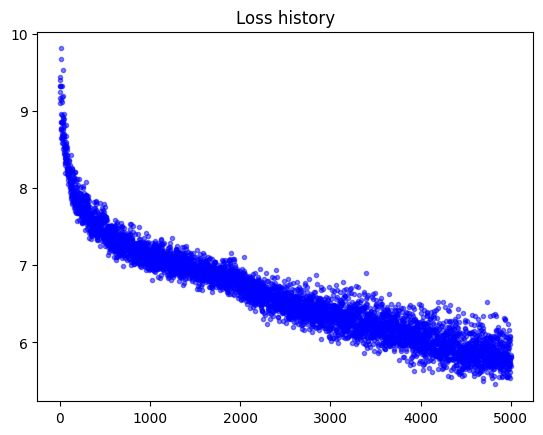

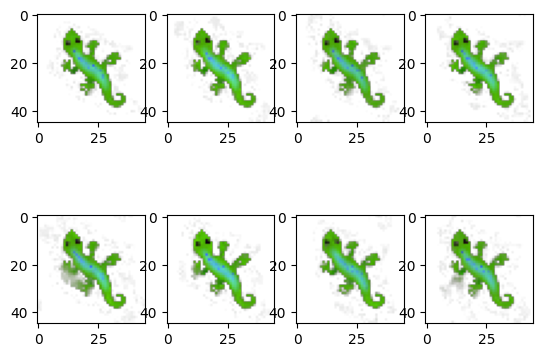

Trained_models/Gene/NCA_EBM.pth


In [15]:
#@title Training { vertical-output: true}

lambda_mono = 0.05
lambda_drift = 0.05
K = 20


eta_log = []
energy_loss = []
loss_mono_log = []
loss_drift_log = []

for i in range(TRAINING_ITERS + 1):
    with torch.no_grad():
        batch = pool.sample(BATCH_SIZE)
        x = torch.from_numpy(batch.x).to(DEVICE)

    T = random.randrange(32, 92)

    energies = []
    for t in range(T):
        E_t = nca.energy(x)
        energies.append(E_t)
        x = nca(x)

    live_mask = (base[:, 3:4] > 0.1).float()
    per_sample_loss = (((base - x[:, :4, :, :]))*live_mask).pow(2).sum(dim=[1, 2, 3]) + \
        0.1 * (perchannel_conv(base, filters) - perchannel_conv(x[:, :4, :, :], filters)).pow(2).mean(dim=[1, 2, 3])

    loss_recon = per_sample_loss.sum()

    energies_t = torch.stack(energies[:-1])
    energies_t1 = torch.stack(energies[1:])
    loss_mono = torch.relu(energies_t1 - energies_t).sum()

    loss_drift = 0
    for t in range(K):
      x = nca(x)
      loss_drift = loss_drift + ((base - x[:, :4, :, :]) ).pow(2).sum()

    loss = loss_recon + lambda_mono * loss_mono + lambda_drift * loss_drift
    loss.backward()
    torch.nn.utils.clip_grad_norm_(nca.parameters(), max_norm=1.0)
    optim.step()
    optim.zero_grad()

    eta_log.append(nca.eta.detach().item())
    loss_mono_log.append(loss_mono.item())
    loss_drift_log.append(loss_drift.item())
    energy_loss.append(loss.item())
    loss_log.append(loss.log().item())

    with torch.no_grad():
        loss_rank = per_sample_loss.detach().cpu().numpy().argsort()[::-1]
        x_np = x.detach().cpu().numpy()[loss_rank]
        x_np[:1] = seed
        batch.x[:] = x_np
        batch.commit()
    scheduler.step()



    if i % 100 == 0:
        print(f"Training itter {i}, loss = {loss.item()}")
        plt.clf()
        clear_output()
        plt.figure(1, figsize=(10, 4))
        plt.title('Loss history')
        plt.plot(loss_log, '.', alpha=0.5, color="b")
        print("Batch")
        utils.show_batch(x[2:14])
        display(HTML(style))
        plt.show(block=False)
        plt.pause(0.01)


    if i % 100 == 0:
        torch.save(nca.state_dict(), "Trained_models/" + name + ".pth")
        print("Trained_models/" + name + ".pth")


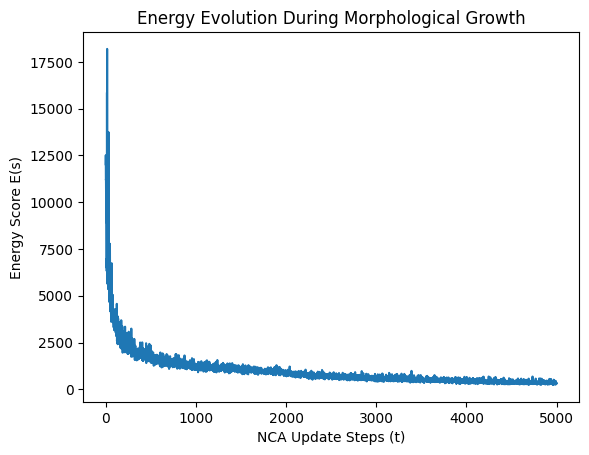

In [16]:

plt.plot(energy_loss)
plt.xlabel("NCA Update Steps (t)")
plt.ylabel("Energy Score E(s)")
plt.title("Energy Evolution During Morphological Growth")
plt.show()


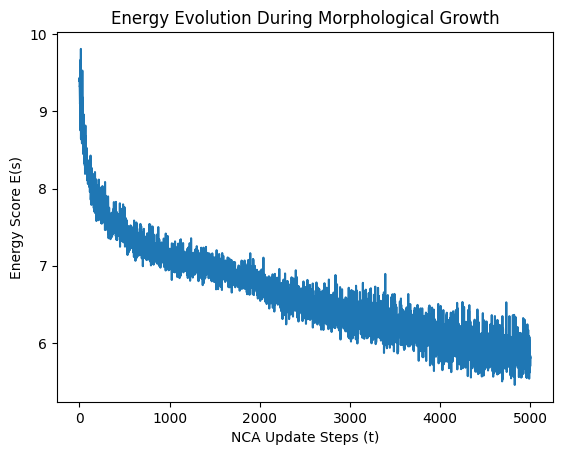

In [17]:
plt.plot(loss_log)
plt.xlabel("NCA Update Steps (t)")
plt.ylabel("Energy Score E(s)")
plt.title("Energy Evolution During Morphological Growth")
plt.show()

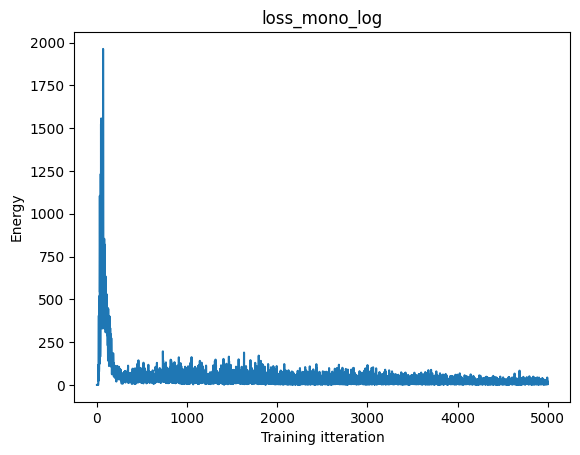

In [18]:
plt.plot(loss_mono_log)
plt.title("loss_mono_log")
plt.xlabel("Training itteration")
plt.ylabel("Energy")
plt.show()

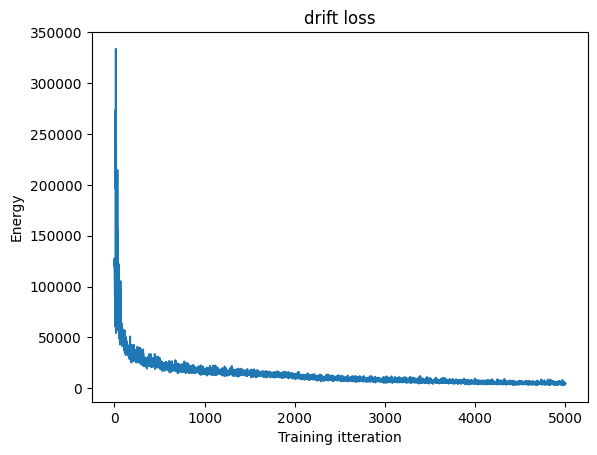

In [19]:
plt.plot(loss_drift_log)
plt.title("drift loss")
plt.xlabel("Training itteration")
plt.ylabel("Energy")
plt.show()

In [27]:
nca = NCA_EBM(CHANNELS,hidden_n=HIDDEN_SIZE)
nca.load_state_dict(torch.load("Trained_models/Gene/NCA_EBM.pth"))
nca.to(DEVICE).eval()

NCA_EBM(
  (w1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  (w2): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
)

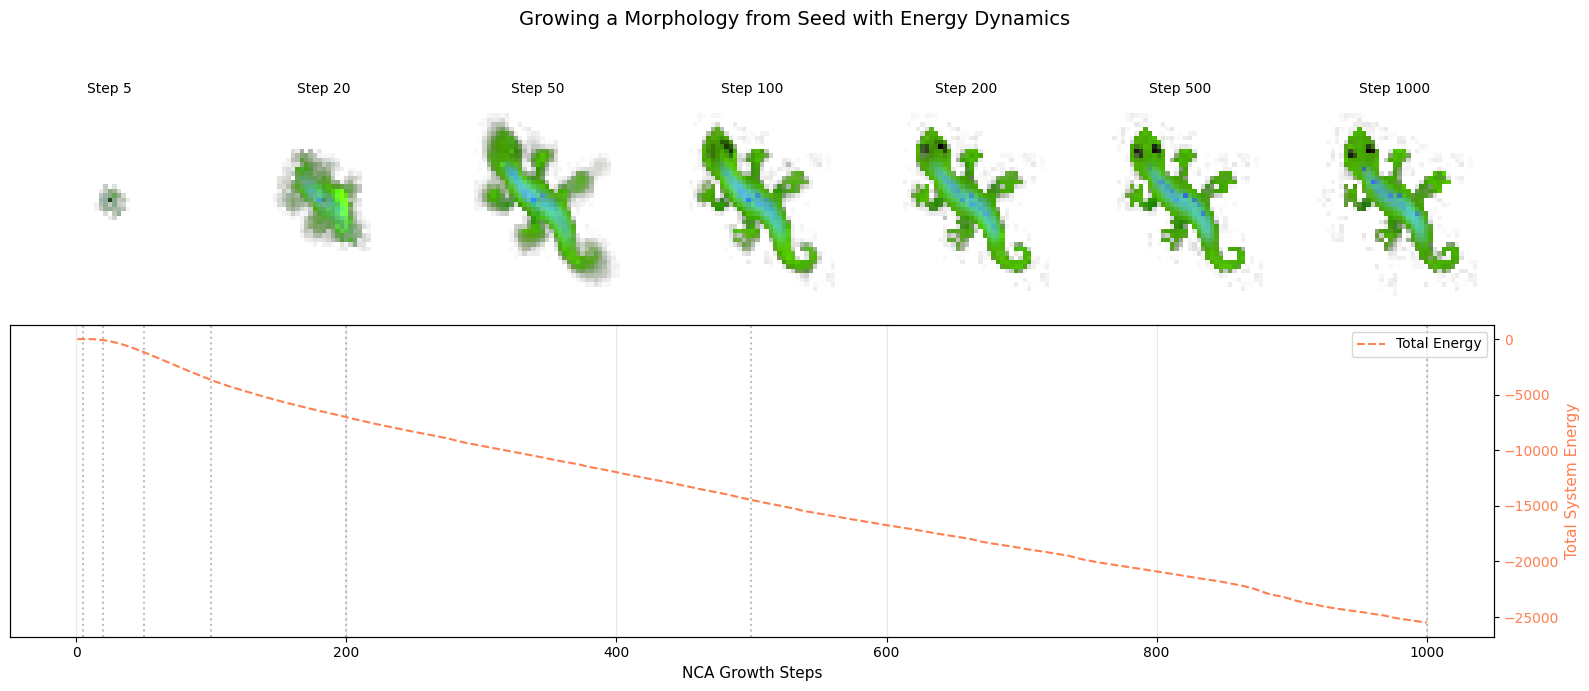

In [50]:
## Growing the morphology
def visualize_growth(nca, seed, steps_to_show=[5, 20, 50, 100, 200, 500, 1000], device=DEVICE):
    x = torch.from_numpy(seed[None, ...]).to(device) if isinstance(seed, np.ndarray) else seed.to(device)

    # 2 rows: Top row for visual states, Bottom row spanning for Energy plot
    fig = plt.figure(figsize=(16, 7))
    fig.suptitle("Growing a Morphology from Seed with Energy Dynamics", fontsize=14, y=0.98)

    max_steps = max(steps_to_show)
    total_energy_history = []
    mean_energy_history = []
    captured_frames = []

    # Run step-by-step up to max_steps to record full continuous trajectory
    with torch.no_grad():
        for step in range(1, max_steps + 1):
            x = nca(x)

            # Record Energy metrics
            E = nca.energy(x)
            if torch.is_tensor(E):
                total_energy_history.append(E.sum().item())

            # Capture frame at requested steps
            if step in steps_to_show:
                img = x[0, :4].permute(1, 2, 0).cpu().numpy()
                img = np.clip(img, 0, 1)
                captured_frames.append((step, img))

    # --- 1. Top Row: Morphological Snapshots ---
    n_snapshots = len(steps_to_show)
    for i, (step, img) in enumerate(captured_frames):
        ax = fig.add_subplot(2, n_snapshots, i + 1)
        ax.imshow(img)
        ax.set_title(f"Step {step}", fontsize=10)
        ax.axis("off")

    # --- 2. Bottom Row: Continuous Energy Progression ---
    ax_energy = fig.add_subplot(2, 1, 2)
    steps_range = range(1, max_steps + 1)

    # Remove left y-axis labels and ticks
    ax_energy.set_yticks([])

    # Primary axis styling
    ax_energy.set_xlabel("NCA Growth Steps", fontsize=11)
    ax_energy.grid(True, alpha=0.3)

    # Secondary axis: Total System Energy
    ax_total = ax_energy.twinx()
    line2 = ax_total.plot(
        steps_range,
        total_energy_history,
        color='coral',
        linewidth=1.5,
        linestyle='--',
        label='Total Energy'
    )
    ax_total.set_ylabel("Total System Energy", color='coral', fontsize=11)
    ax_total.tick_params(axis='y', labelcolor='coral')

    # Add milestone markers for captured steps
    for s in steps_to_show:
        ax_energy.axvline(x=s, color='gray', linestyle=':', alpha=0.5)

    # Legend setup
    lines = line2
    labels = [l.get_label() for l in lines]
    ax_energy.legend(lines, labels, loc='upper right')

    plt.tight_layout()
    plt.show()

visualize_growth(nca, seed)


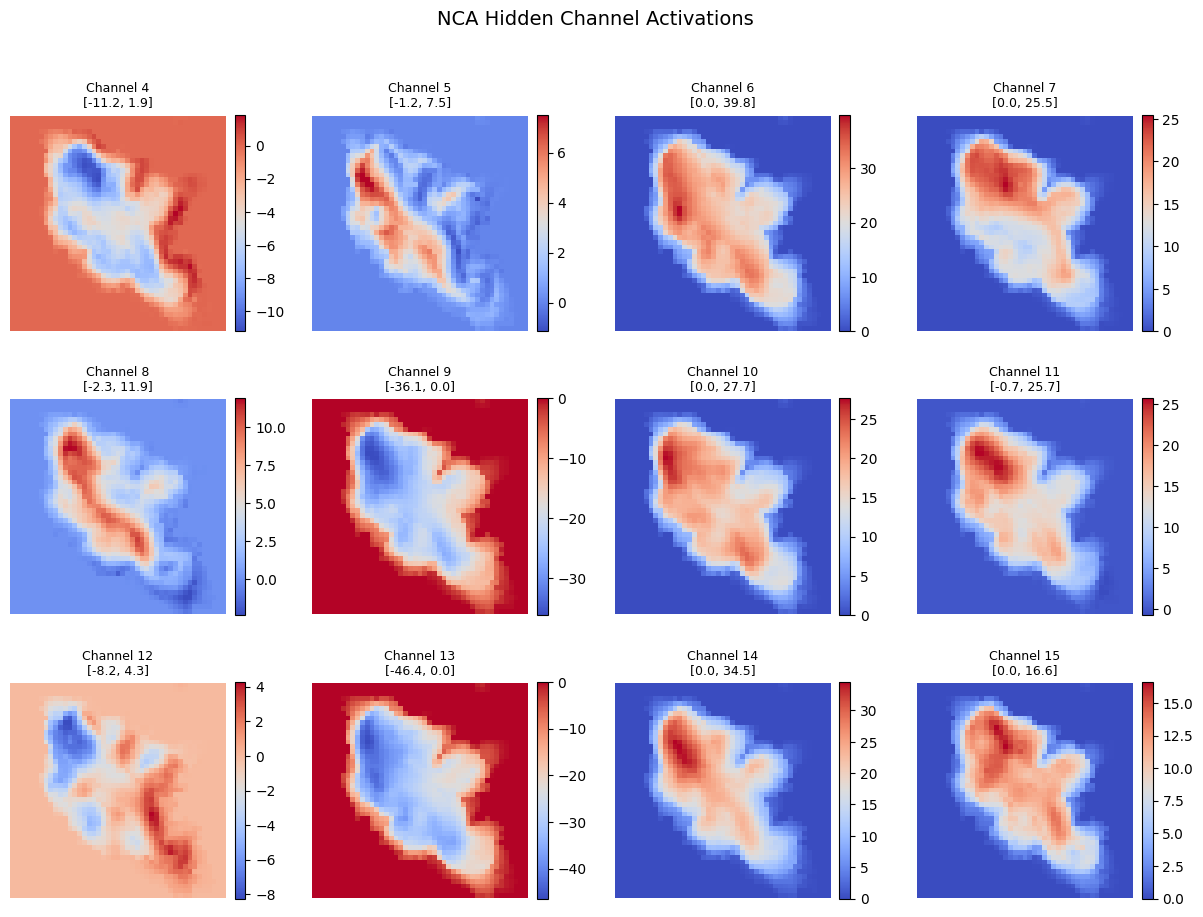

In [42]:
with torch.no_grad():
    for t in range(400):
        x = nca(x)

# 2. Extract Hidden Channels (assuming channels 0..3 are RGBA)
# x shape: (1, total_channels, H, W)
hidden_channels = x[0, 4:].cpu().numpy()  # shape: (num_hidden_channels, H, W)
num_hidden = hidden_channels.shape[0]

# 3. Create a Grid of Heatmaps
cols = 4  # Display 4 heatmaps per row
rows = (num_hidden + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for i in range(num_hidden):
    channel_data = hidden_channels[i]

    # Use a diverging colormap like 'coolwarm' or 'seismic' centered at 0
    # or 'viridis' to see relative magnitudes
    im = axes[i].imshow(channel_data, cmap='coolwarm')

    # Show min/max values in title to easily spot exploding values
    c_min, c_max = channel_data.min(), channel_data.max()
    axes[i].set_title(f"Channel {i+4}\n[{c_min:.1f}, {c_max:.1f}]", fontsize=9)
    axes[i].axis('off')

    # Optional: Add colorbar per subplot to inspect absolute values
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

# Turn off any unused subplots
for i in range(num_hidden, len(axes)):
    axes[i].axis('off')

plt.suptitle("NCA Hidden Channel Activations", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [34]:
## Damage experiments

def apply_damage(x, damage_type='right_half', circle_radius=5):
    """
    Apply different damage patterns to a cell state.

    damage_type options:
        'right_half'   — remove right half (your original)
        'left_half'    — remove left half
        'center_circle'— remove a circle from the center
        'small_circle' — remove a small circle (severe local damage)
        'random'       — randomly zero out 50% of cells
        'cross'        — remove a cross through the center
    """
    x = x.clone()
    _, _, H, W = x.shape
    cy, cx = H // 2, W // 2  # center coordinates

    if damage_type == 'right_half':
        x[:, :, :, W//2:] = 0

    elif damage_type == 'left_half':
        x[:, :, :, :W//2] = 0

    elif damage_type == 'center_circle':
        # Remove a large circle from center
        y_grid, x_grid = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) <= circle_radius**2
        x[:, :, mask] = 0

    elif damage_type == 'small_circle':
        # Severe: remove a tiny circle — forces regeneration from very little
        y_grid, x_grid = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) > circle_radius**2
        x[:, :, mask] = 0  # keep ONLY the small circle, destroy everything else

    elif damage_type == 'random':
        noise = torch.rand(1, 1, H, W, device=x.device) > 0.5
        x = x * noise.float()

    elif damage_type == 'cross':
        thickness = max(1, H // 10)
        x[:, :, cy - thickness:cy + thickness, :] = 0
        x[:, :, :, cx - thickness:cx + thickness] = 0

    return x


def visualize_regeneration(nca, seed, base, damage='right_half',
                            total_steps=400, damage_step=200,
                            circle_radius=5, device=DEVICE):

    x = torch.from_numpy(seed[None, ...]).to(device) if isinstance(seed, np.ndarray) else seed.to(device)

    # Target grid live mask for loss calculation
    live_mask = (base[:, 3:4] > 0.1).float()

    loss_history = []
    energy_history = []

    frames = []
    frame_titles = []

    capture_steps = [0, damage_step - 1, damage_step, damage_step + 25, damage_step + 50, total_steps - 1]

    with torch.no_grad():
        for t in range(total_steps):

            if t == damage_step:
                x = apply_damage(x, damage_type=damage, circle_radius=circle_radius)


            x = nca(x)


            E = nca.energy(x)
            if torch.is_tensor(E):
                E = E.mean().item()
            energy_history.append(E)

            l = ((base[:, 3:4] - x[:, :4]) * live_mask).pow(2).mean().item()
            loss_history.append(l)

            if t in capture_steps:
                frame_img = x[0, :4].permute(1, 2, 0).cpu().clip(0, 1).numpy()
                frames.append(frame_img)

                if t < damage_step:
                    frame_titles.append(f't={t} (Growth)')
                elif t == damage_step:
                    frame_titles.append(f't={t} (Damaged)')
                else:
                    frame_titles.append(f't={t} (+{t - damage_step})')

    fig = plt.figure(figsize=(20, 10))

    n_frames = len(frames)
    for i, (frame, title) in enumerate(zip(frames, frame_titles)):
        ax = fig.add_subplot(2, n_frames, i + 1)
        ax.imshow(frame)
        ax.set_title(title, fontsize=10)
        ax.axis('off')

    ax_loss = fig.add_subplot(2, 2, 3)
    ax_loss.plot(loss_history, color='crimson', linewidth=1.5, label='MSE Loss')
    ax_loss.axvline(x=damage_step, color='black', linestyle='--', label='Damage Applied')
    ax_loss.set_title("Reconstruction Loss (Growth -> Damage -> Recovery)")
    ax_loss.set_xlabel("Total NCA Steps")
    ax_loss.set_ylabel("MSE Loss")
    ax_loss.grid(True, alpha=0.3)
    ax_loss.legend()

    ax_energy = fig.add_subplot(2, 2, 4)
    ax_energy.plot(energy_history, color='teal', linewidth=1.5, label='Energy')
    ax_energy.axvline(x=damage_step, color='black', linestyle='--', label='Damage Applied')
    ax_energy.set_title("System Energy Profile")
    ax_energy.set_xlabel("Total NCA Steps")
    ax_energy.set_ylabel("Energy")
    ax_energy.grid(True, alpha=0.3)
    ax_energy.legend()

    plt.tight_layout()
    plt.show()

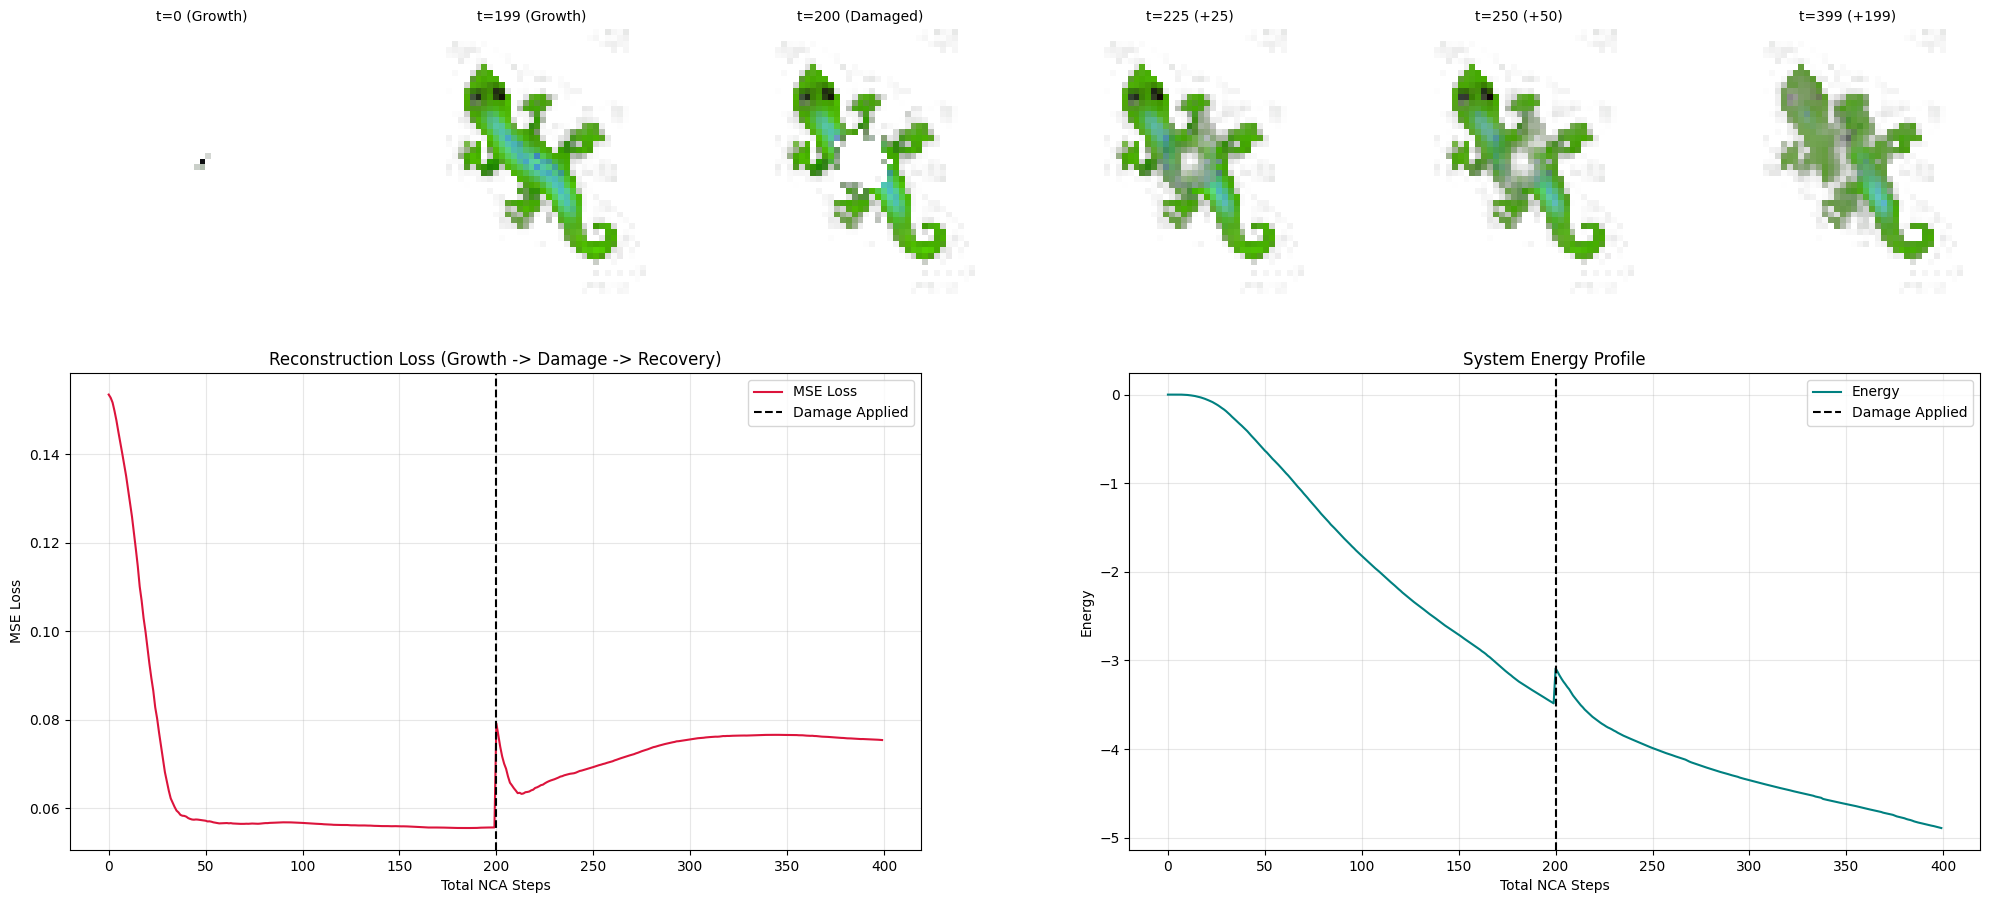

In [35]:
visualize_regeneration(nca, seed, base, "center_circle")

In [23]:
del nca
del optim
torch.cuda.empty_cache()